<a href="https://colab.research.google.com/github/candrajulius/Pengenalan_Expresi_Wajah_Dengan_Model_AlexNet/blob/main/Pengenalan_Face_Expression_Dengan_AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mengecek GPU
import tensorflow as tf
tf.test.gpu_device_name()

'/device:GPU:0'

In [2]:
# Install Data From Kaggle
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"matthew2702","key":"97c7c53c94c33ecaa06af987790417ff"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [5]:
!kaggle datasets download -d davilsena/ckdataset

Dataset URL: https://www.kaggle.com/datasets/davilsena/ckdataset
License(s): CC0-1.0


In [6]:
file_name = 'ckdataset.zip'

In [7]:
from zipfile import ZipFile
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('Selesai mengekstrak zip')

Selesai mengekstrak zip


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  920 non-null    int64 
 1   pixels   920 non-null    object
 2   Usage    920 non-null    object
dtypes: int64(1), object(2)
memory usage: 21.7+ KB
None
          emotion
count  920.000000
mean     4.920652
std      1.882630
min      0.000000
25%      5.000000
50%      6.000000
75%      6.000000
max      7.000000
emotion    0
pixels     0
Usage      0
dtype: int64
emotion
0     45
1     59
2     25
3     69
4     28
5     83
6    593
7     18
Name: count, dtype: int64


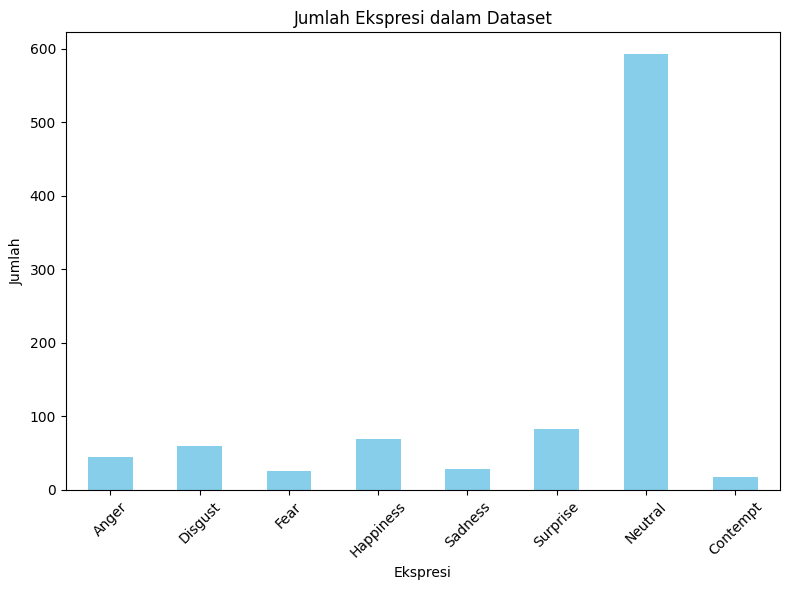

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca CSV
df = pd.read_csv('ckextended.csv')

# Gather information about dataset
print(df.info())
print(df.describe())
print(df.isnull().sum())

emotion_labels = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happiness",
    4: "Sadness",
    5: "Surprise",
    6: "Neutral",
    7: "Contempt"
}

print(df['emotion'].value_counts().sort_index())

expression = df['emotion'].value_counts().sort_index()
expression.index = expression.index.map(emotion_labels)

# Buat bar chart
plt.figure(figsize=(8,6))
expression.plot(kind='bar', color='skyblue')
plt.title('Jumlah Ekspresi dalam Dataset')
plt.xlabel('Ekspresi')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

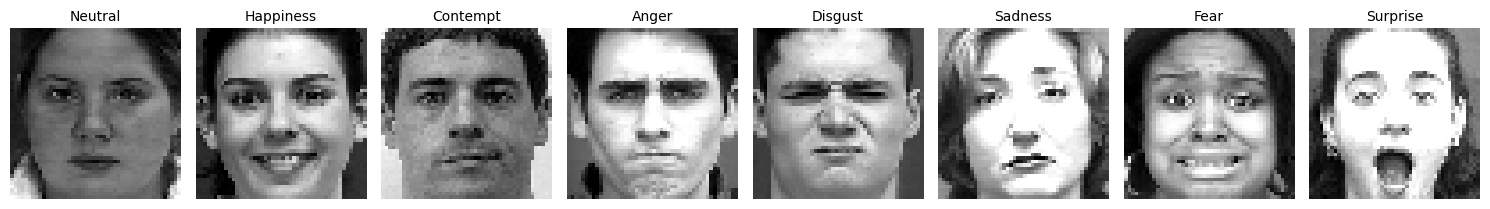

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Buat dict untuk simpan gambar sample per label
samples = {}

# Loop semua baris, ambil satu sample per label
for _, row in df.iterrows():
    label = row['emotion']
    if label not in samples:
        # Ubah string pixel menjadi array
        pixels = np.array(row['pixels'].split(), dtype='float32')
        image = pixels.reshape(48, 48)  # ukuran default FER-2013
        samples[label] = image

    if len(samples) == len(emotion_labels):
        break  # sudah cukup semua label

# Tampilkan
plt.figure(figsize=(15, 5))
for idx, (label, image) in enumerate(samples.items()):
    plt.subplot(1, len(samples), idx + 1)
    plt.imshow(image, cmap='gray')
    plt.title(emotion_labels[label], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
X = df['pixels'].apply(lambda x: np.fromstring(x, sep=' '))
X = np.array([i for i in X])  # Ubah daftar (list) menjadi array numpy
y = df['emotion']

In [11]:
# Ubah gambar ke ukuran 48x48 (setiap gambar terdiri dari 48x48 = 2304 piksel)
X = X.reshape(-1, 48, 48, 1).astype('float32')

In [12]:
# Normalisasi data (mengubah nilai piksel dari rentang 0–255 ke rentang 0–1)
X /= 255.0

In [13]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
# Ubah label menjadi bentuk kategorikal (one-hot encoding)
y = to_categorical(y, num_classes=8)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Eğitim verisi boyutu: {X_train.shape}')
print(f'Test verisi boyutu: {X_test.shape}')

Eğitim verisi boyutu: (736, 48, 48, 1)
Test verisi boyutu: (184, 48, 48, 1)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

model = Sequential()

# Layer 1: Conv + ReLU + Pool
model.add(Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01), input_shape=(48, 48, 1)))
model.add(MaxPooling2D((2, 2)))

# Layer 2: Conv + ReLU + Pool
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Layer 3: Conv + ReLU + Pool
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# FC Layer
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(8, activation='softmax'))

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,471,432 (9.43 MB)

 Trainable params: 2,471,432 (9.43 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step - accuracy: 0.5163 - loss: 1.8134 - val_accuracy: 0.6413 - val_loss: 1.4608
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6579 - loss: 1.4156 - val_accuracy: 0.6413 - val_loss: 1.3756
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6467 - loss: 1.3847 - val_accuracy: 0.6413 - val_loss: 1.3595
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6392 - loss: 1.3679 - val_accuracy: 0.6413 - val_loss: 1.3578
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6499 - loss: 1.3178 - val_accuracy: 0.6413 - val_loss: 1.3489
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6470 - loss: 1.3365 - val_accuracy: 0.6413 - val_loss: 1.3459
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6610 - loss: 1.3039 - val_accuracy: 0.6413 - val_loss: 1.3416
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6470 - loss: 1.3417 - val_accuracy: 0.6413 - 

In [18]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


# Confusion Matrix Testing

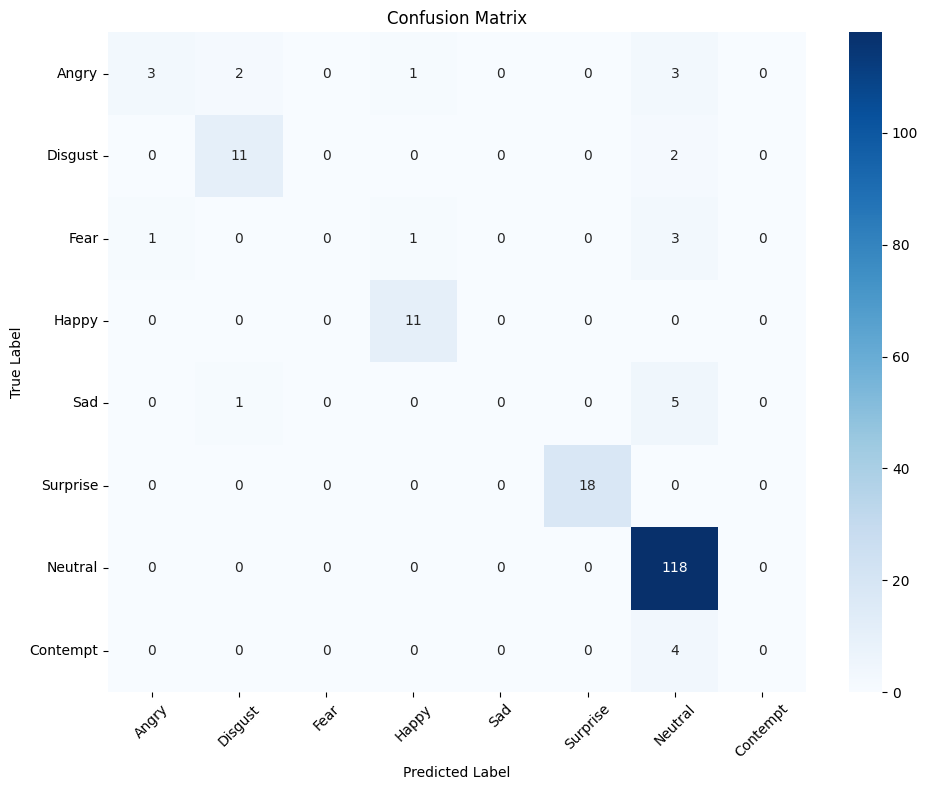


Classification Report:
              precision    recall  f1-score   support

       Angry       0.75      0.33      0.46         9
     Disgust       0.79      0.85      0.81        13
        Fear       0.00      0.00      0.00         5
       Happy       0.85      1.00      0.92        11
         Sad       0.00      0.00      0.00         6
    Surprise       1.00      1.00      1.00        18
     Neutral       0.87      1.00      0.93       118
    Contempt       0.00      0.00      0.00         4

    accuracy                           0.88       184
   macro avg       0.53      0.52      0.52       184
weighted avg       0.80      0.88      0.83       184



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# label dataset
class_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral', 'Contempt']

# Confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=class_labels))

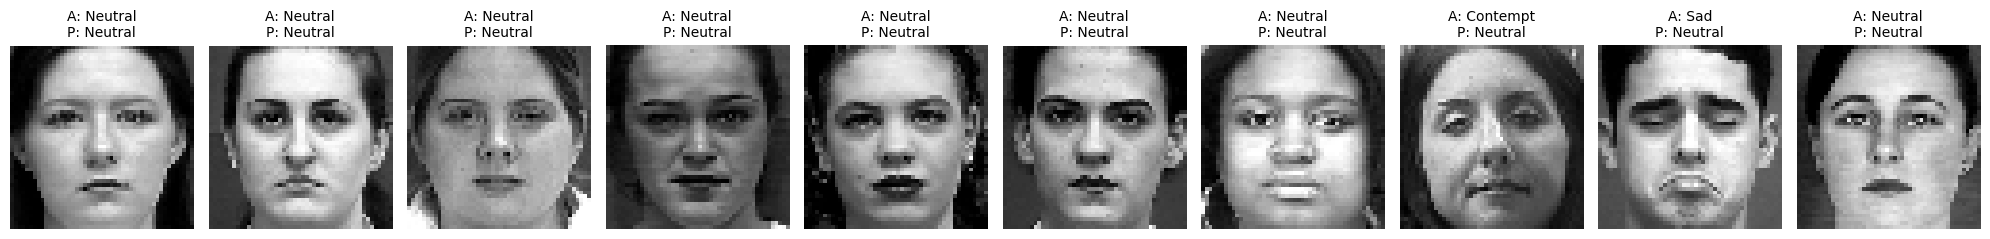

In [44]:
# Tampilkan 15 gambar pertama dengan prediksinya testing
jumlah_gambar = 10
plt.figure(figsize=(20, 3))  # lebar 15, tinggi 3
for i in range(jumlah_gambar):
    plt.subplot(1, jumlah_gambar, i+1)
    plt.imshow(X_test[i].reshape(48, 48), cmap='gray')
    actual = class_labels[y_test_classes[i]]
    predicted = class_labels[y_pred_classes[i]]
    plt.title(f"A: {actual}\nP: {predicted}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [22]:
y_pred = model.predict(X_train)
y_pred_classes_train = np.argmax(y_pred, axis=1)
y_train_classes = np.argmax(y_train, axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


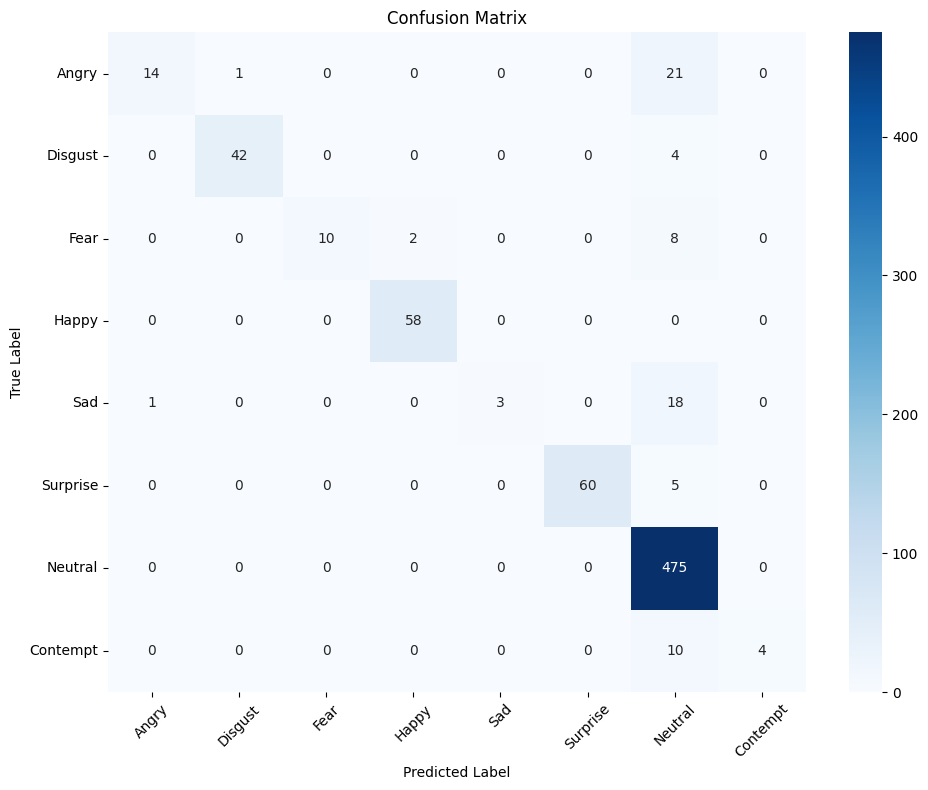


Classification Report:
              precision    recall  f1-score   support

       Angry       0.93      0.39      0.55        36
     Disgust       0.98      0.91      0.94        46
        Fear       1.00      0.50      0.67        20
       Happy       0.97      1.00      0.98        58
         Sad       1.00      0.14      0.24        22
    Surprise       1.00      0.92      0.96        65
     Neutral       0.88      1.00      0.94       475
    Contempt       1.00      0.29      0.44        14

    accuracy                           0.90       736
   macro avg       0.97      0.64      0.72       736
weighted avg       0.91      0.90      0.89       736



In [38]:
# Label kelas (ganti sesuai dataset kamu ya)
class_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral', 'Contempt']

# Confusion matrix
cm = confusion_matrix(y_train_classes, y_pred_classes_train)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_train_classes, y_pred_classes_train, target_names=class_labels))

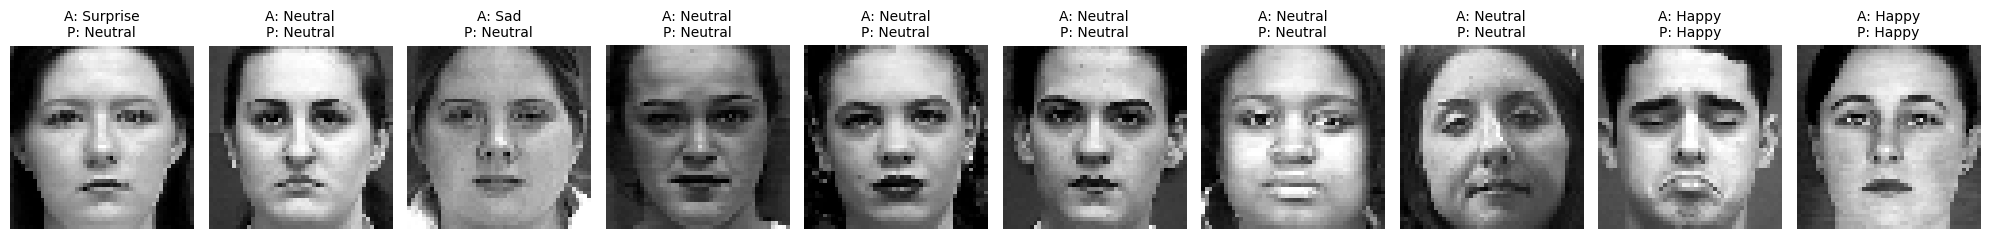

In [43]:
# Tampilkan 10 gambar pertama dengan prediksinya training
jumlah_gambar = 10
plt.figure(figsize=(20, 3))  # lebar 15, tinggi 3
for i in range(jumlah_gambar):
    plt.subplot(1, jumlah_gambar, i+1)
    plt.imshow(X_test[i].reshape(48, 48), cmap='gray')
    actual = class_labels[y_train_classes[i]]
    predicted = class_labels[y_pred_classes_train[i]]
    plt.title(f"A: {actual}\nP: {predicted}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [39]:
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f'Akurasi Training: {train_accuracy * 100:.2f}%')

# Evaluasi akurasi testing
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Akurasi Testing: {test_accuracy * 100:.2f}%')

Akurasi Training: 90.49%
Akurasi Testing: 87.50%


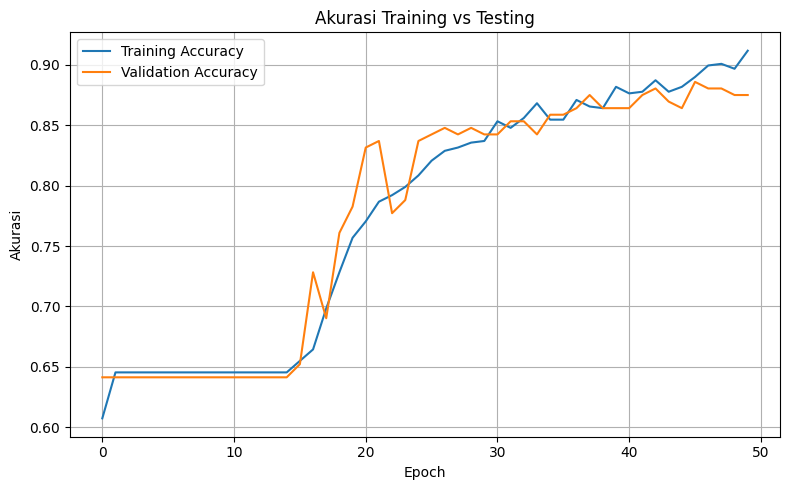

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Akurasi Training vs Testing')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

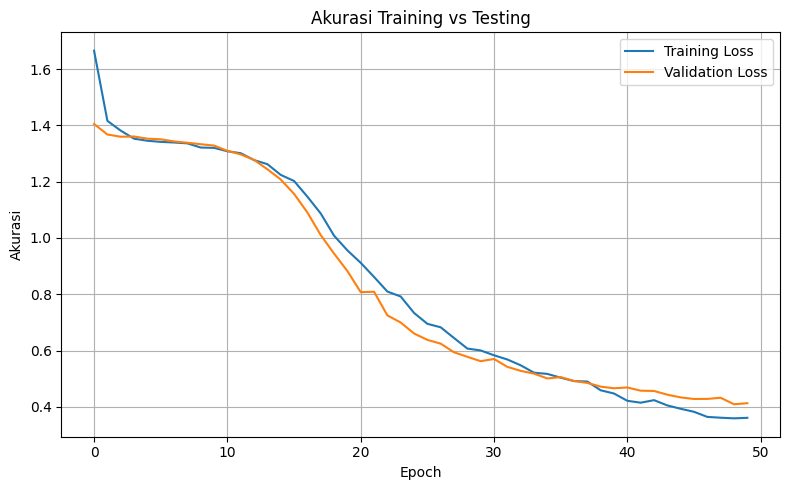

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Akurasi Training vs Testing')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()